# Visualização da spline Catmull–Rom 3D da pá

Este notebook desenha uma spline 3D usando Catmull–Rom a partir dos parâmetros:

- `blade_length`
- `leading_edge_blade_width`
- `trailing_edge_blade_width`
- `leading_edge_blade_xoffset`
- `trailing_edge_blade_xoffset`

A construção dos pontos de controle foi organizada para ficar **o mais parecida possível**
com um perfil de pá típico em OpenSCAD. Se o seu código tiver alguma fórmula diferente
(por exemplo, fatores de escala, offsets adicionais, etc.), basta ajustar a função
`build_control_points()` para reproduzir exatamente o seu `catmull-rom3d`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necessário para 3D)


In [2]:
def catmull_rom3d(u, P0, P1, P2, P3):
    """
    Versão Python da função catmull_rom3d do OpenSCAD.
    P0..P3 são arrays ou listas [x, y, z].
    u é escalar (0..1).
    """
    u2 = u * u
    u3 = u2 * u

    x = 0.5 * (2*P1[0] + (-P0[0] + P2[0]) * u +
               (2*P0[0] - 5*P1[0] + 4*P2[0] - P3[0]) * u2 +
               (-P0[0] + 3*P1[0] - 3*P2[0] + P3[0]) * u3)

    y = 0.5 * (2*P1[1] + (-P0[1] + P2[1]) * u +
               (2*P0[1] - 5*P1[1] + 4*P2[1] - P3[1]) * u2 +
               (-P0[1] + 3*P1[1] - 3*P2[1] + P3[1]) * u3)

    z = 0.5 * (2*P1[2] + (-P0[2] + P2[2]) * u +
               (2*P0[2] - 5*P1[2] + 4*P2[2] - P3[2]) * u2 +
               (-P0[2] + 3*P1[2] - 3*P2[2] + P3[2]) * u3)

    return np.array([x, y, z])

In [3]:
def toroidal_path_spline_3d(
    t,
    hub_d,
    hub_height,
    blade_length,
    leading_edge_blade_width_pct,
    trailing_edge_blade_width_pct,
    leading_edge_blade_xoffset_pct,
    trailing_edge_blade_xoffset_pct
):
    """
    Replica a função toroidal_path_spline_3d do OpenSCAD.
    t em [0, 1].
    Todos os parâmetros em mm e %, como no SCAD.
    """
    # offsets em Y convertidos de %
    leadW  = blade_length * (leading_edge_blade_width_pct  / 100.0)
    trailW = blade_length * (trailing_edge_blade_width_pct / 100.0)

    # offsets em X convertidos de %
    leadX  = blade_length * (leading_edge_blade_xoffset_pct  / 100.0)
    trailX = blade_length * (trailing_edge_blade_xoffset_pct / 100.0)

    # raio do hub (OpenSCAD usa graus, então convertemos)
    r  = hub_d * np.cos(np.deg2rad(30.0)) / 2.0

    # 5 pontos principais (também usando graus)
    A = np.array([r*np.cos(np.deg2rad(60.0)),  r*np.sin(np.deg2rad(60.0)),   hub_height/2.0])
    B = np.array([leadX, +leadW, hub_height/2.0])
    M = np.array([blade_length, 0.0, hub_height/2.0])
    C = np.array([trailX, -trailW, hub_height/2.0])
    D = np.array([r*np.cos(np.deg2rad(60.0)),  r*np.sin(np.deg2rad(-60.0)), hub_height/2.0])

    P = [A, B, M, C, D]

    # segmentação
    segw = 1.0 / 4.0

    if t < segw:
        seg = 0
    elif t < 2*segw:
        seg = 1
    elif t < 3*segw:
        seg = 2
    else:
        seg = 3

    # u local em cada segmento
    if seg == 0:
        u = t / segw
    elif seg == 1:
        u = (t - segw) / segw
    elif seg == 2:
        u = (t - 2*segw) / segw
    else:
        u = (t - 3*segw) / segw

    i0 = 0 if seg == 0 else seg - 1
    i1 = seg
    i2 = seg + 1
    i3 = 4 if (seg + 2 > 4) else seg + 2

    P0 = P[i0]
    P1 = P[i1]
    P2 = P[i2]
    P3 = P[i3]

    return catmull_rom3d(u, P0, P1, P2, P3)

In [4]:
def toroidal_path_points(
    steps,
    hub_d,
    hub_height,
    blade_length,
    leading_edge_blade_width_pct,
    trailing_edge_blade_width_pct,
    leading_edge_blade_xoffset_pct,
    trailing_edge_blade_xoffset_pct,
    t_start=0.0,
    t_end=1.0
):
    """
    Equivalente Python da função toroidal_path_points do OpenSCAD.
    Retorna um array (steps+1, 3) com pontos [x,y,z].
    """
    pts = []
    for i in range(steps + 1):
        u = i / steps
        t = t_start + (t_end - t_start) * u
        p = toroidal_path_spline_3d(
            t,
            hub_d,
            hub_height,
            blade_length,
            leading_edge_blade_width_pct,
            trailing_edge_blade_width_pct,
            leading_edge_blade_xoffset_pct,
            trailing_edge_blade_xoffset_pct
        )
        pts.append(p)
    return np.array(pts)

In [5]:
# Parâmetros equivalentes ao exemplo que você passou:
hub_d = 16
hub_height = 6
blade_length = 68

leading_edge_blade_width  = 18   # %
trailing_edge_blade_width = 18   # %
leading_edge_blade_xoffset = 50  # % da blade_length
trailing_edge_blade_xoffset = 25 # % da blade_length

path_steps  = 200    # resolução da curva
path_portion = 1.0   # mesma ideia do path_portion = 1.0 no SCAD

# Gera os pontos do caminho toroidal
path_points = toroidal_path_points(
    steps=path_steps,
    hub_d=hub_d,
    hub_height=hub_height,
    blade_length=blade_length,
    leading_edge_blade_width_pct=leading_edge_blade_width,
    trailing_edge_blade_width_pct=trailing_edge_blade_width,
    leading_edge_blade_xoffset_pct=leading_edge_blade_xoffset,
    trailing_edge_blade_xoffset_pct=trailing_edge_blade_xoffset,
    t_start=0.0,
    t_end=path_portion
)

# Separa X, Y, Z
X = path_points[:, 0]
Y = path_points[:, 1]
Z = path_points[:, 2]

## Plot 3D da spline

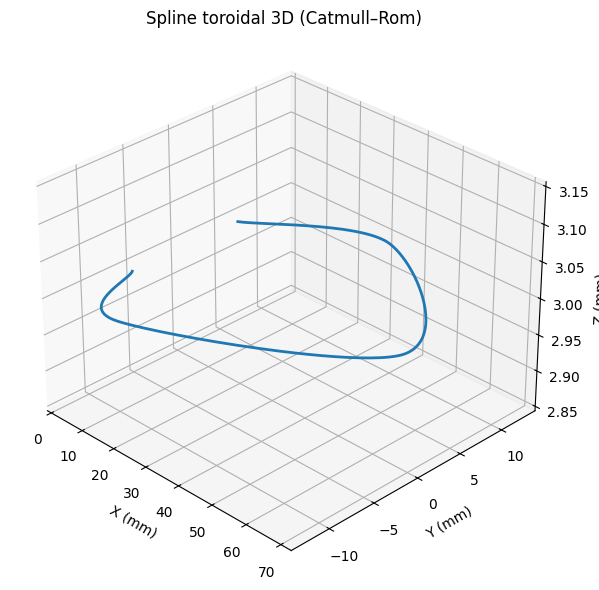

In [6]:
# %%
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X, Y, Z, linewidth=2)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.set_title("Spline toroidal 3D (Catmull–Rom)")

ax.view_init(elev=30, azim=-45)  # ângulo de visão inicial (ajuste à vontade)
plt.tight_layout()
plt.show()

## Projeção XY

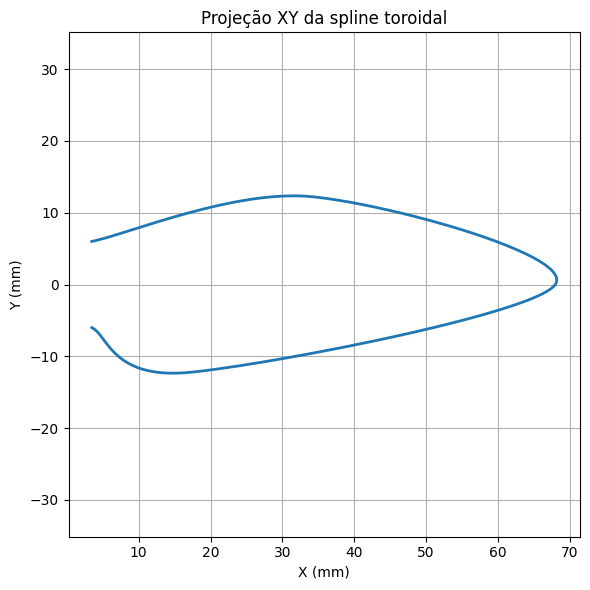

In [7]:
plt.figure(figsize=(6, 6))
plt.plot(X, Y, linewidth=2)
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("Projeção XY da spline toroidal")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()

## Projeção YZ

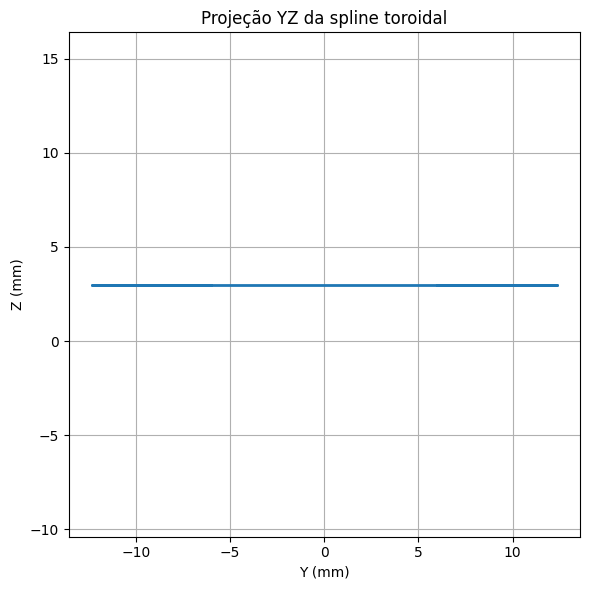

In [8]:
plt.figure(figsize=(6, 6))
plt.plot(Y, Z, linewidth=2)
plt.xlabel("Y (mm)")
plt.ylabel("Z (mm)")
plt.title("Projeção YZ da spline toroidal")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()